## 0. Import and Definitions

In [ ]:
import os
import copy
from sklearn.metrics import roc_curve, auc

import scanpy as sc
import anndata as ad
from mudata import MuData

import numpy as np
import matplotlib.pyplot as plt

from src.analysis.mmd import ctrl_mmd_dists, mmd_dists, plot_mmd_dists
from src.analysis.analysis_utils import (
    Analyzer,
)
from src.analysis.logistic_regression import (
    train_classifier,
    generate_counterfactuals,
    init_classifier,
    evaluate_training_error,
)
from src.analysis.cluster_analysis import (
    plot_latent_means_umap,
)

from src.model.data_utils import (
    load_data,
    get_condition_shapes,
    prepare_train_test_data,
    build_metacells,
    create_latent_adata,
)
from src.model.training import train_model
from src.model.build_model import get_model, remap_keys, init_config
from src.model.config import INNConfig
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_top_deg_violin,
    sample_from_means,
)

import warnings
import socket
import torch

from sklearn.decomposition import PCA

assert "login" not in socket.gethostname()

warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
adata = None
analyzer = None

## 1. Load Data

In [ ]:
USE_METACELLS = False
DONOR = ["Donor1"]

In [ ]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

In [ ]:
if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=None,
        donors=DONOR,
    )
    print(adata.X.shape)
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

mdata = MuData({"rna": adata})
dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

## 2. Model

### 2.1 Setup

In [ ]:
dataset_args["sigma_noise"] = 0.1
dataset_args["lam_MTC"] = 0.3
dataset_args["use_counts"] = False
dataset_args["batch_size"] = 1024
prefix = ""

In [7]:
conditions = [f"{labels_key}"]
condition_shapes = None
condition_type = None
if conditions is not None:
    condition_shapes = get_condition_shapes(adata, conditions)
    condition_type = "mixture"
    trainable_means = True
    trainable_simga = True
print("Condition shapes:", condition_shapes)

supervise_latent_meaning = "partition"
lam_supervise = 0.01

Condition shapes: [11]


In [8]:
test_size = 0.0

dataset, dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    adata,
    dataset_args["batch_size"],
    device,
    dtype,
    counts=dataset_args["use_counts"],
    label_key=conditions,
    test_size=test_size,
)
D_dim = dataset.X.shape[1]
N_dim = D_dim

In [9]:
dataset_name = dataset_args["dataset_name"]
top_genes = min(dataset_args["top_genes"], D_dim)
sigma_noise = dataset_args["sigma_noise"]
lam_MTC = dataset_args["lam_MTC"]

model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes)
)
model_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise) + "_model.pt"

output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)
output_dir_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise)

if dataset_args["use_counts"]:
    model_path += "_counts"
    output_dir_path += "_counts"

model_path += "_best"
output_dir_path += "_best"
print(f"Model path: {model_path}")
print(f"Model name: {model_name}")

plot_dir = os.path.join(output_dir_path, "plots", output_dir_name)
log_dir = os.path.join(output_dir_path, "logs", output_dir_name)
csv_dir = os.path.join(output_dir_path, "csv", output_dir_name)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

checkpoint_path = os.path.join(model_path, model_name)

Model path: /g/stegle/jhoefer/models/EOFlow/parse/top_1779_best
Model name: balanced_MTC_0.3_sigma_0.1_model.pt


In [10]:
kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": sigma_noise,
    "sigma_inflate": sigma_noise,
}

kwargs_loss = {
    "use_NLL": True,
    "use_MER": True,
    "mode_MER": "unbiased",  #'full', #'unbiased'
    "lam_MTC": lam_MTC,
    "lam_ME_i": list(np.zeros(D_dim)),
    # 'use_align': False,
    # 'dims_align': D_dim - 1,
    # 'lam_align': 1, #0.1,
    # 'lam_disent': 0, #0.1,
    "use_rec": False,
    "dims_rec": D_dim - 1,
    "lam_rec": 100,  #
    "sigma_noise": sigma_noise,
}

metrics_loss = {
    "epoch": [],
    "loss": [],
    "z2": [],
    "NLL": [],
    "MTC": [],
    "H_i": [],
    "H_core": [],
    "H_detail": [],
    "MI_core_detail": [],
    "L2_rec": [],
}
val_metrics_loss = metrics_loss.copy()

In [11]:
model_config = INNConfig(
    N_dim=N_dim,
    N_blocks=8,
    condition_shapes=condition_shapes,
    pre_normalize=False,
    normalize=True,
    warmup_steps=2 * len(dataloader),
    condition_type=condition_type,
    trainable_means=trainable_means,
    n_clusters=len(dataset.cats[0].categories),
    lr_means=5e-3,
    supervise_latent_meaning=supervise_latent_meaning,
    ctrl_idx=dataset.cats[0].categories.tolist().index(control_label),
    lam_supervise=lam_supervise,
    trainable_sigma=trainable_simga,
    latent_per_condition=8,
)

flow, optimizer = get_model(model_config)

In [12]:
CONTINUE_TRAINING = False
NUM_EPOCHS = 1
# NUM_EPOCHS = int(NUM_EPOCHS * N_dim / dataset_args["batch_size"])
start_epoch = 0
log_path = None

### 2.2 Train or Load 

In [13]:
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    metrics_loss = checkpoint["metrics_loss"]

    if "val_metrics_loss" in checkpoint:
        val_metrics_loss = checkpoint["val_metrics_loss"]

    log_path = checkpoint["log_path"]
    start_epoch = checkpoint["epoch"] + 1
    model_config = checkpoint["model_config"]

    model_config = init_config(model_config)

    print(f"Checkpoint found at epoch {checkpoint['epoch']}.")

    model, optimizer = get_model(model_config)

    model = model.to(device)
    saved_state = checkpoint["model_state_dict"]

    ## TODO: Remove fix
    # model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model = remap_keys(model, saved_state)

    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])


else:
    print("No checkpoint found, starting training from scratch.")
    model, optimizer = get_model(model_config)
    model = model.to(device)

if CONTINUE_TRAINING:
    print(f"Starting training from epoch {start_epoch}...")

    model, optimizer, metrics_loss, val_metrics_loss, log_path = train_model(
        model,
        optimizer,
        metrics_loss,
        kwargs_data,
        kwargs_loss,
        save_model_path=checkpoint_path,
        model_config=model_config,
        val_metrics_loss=val_metrics_loss,
        num_epochs=NUM_EPOCHS,
        start_epoch=start_epoch,
        print_info=True,
        log_dir=log_dir,
        continue_log_path=log_path,
        conditions=conditions,
    )

Checkpoint found at epoch 550.
Loaded successfully. Missing/fresh keys: []


In [14]:
analyzer = Analyzer(
    adata,
    model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path,
    metrics_loss,
    conditions=conditions,
    condition_type=model_config.condition_type,
    val_metrics_loss=val_metrics_loss,
)

## 3. Evaluation

### 3.1 Clusters

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 1779 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


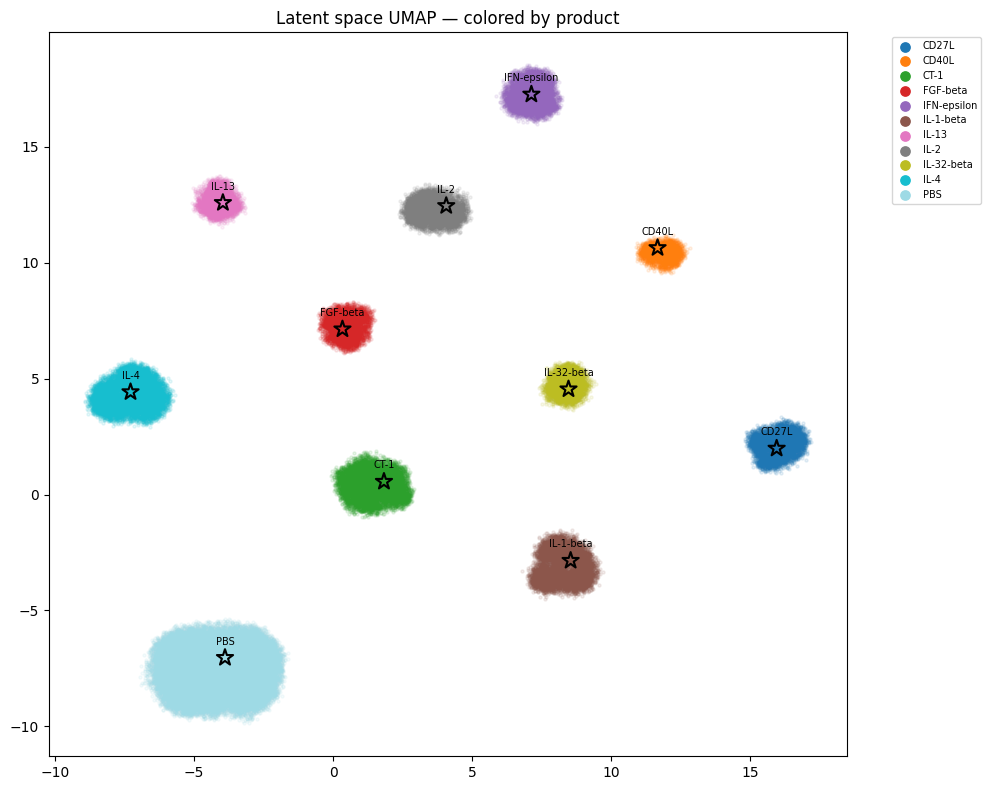

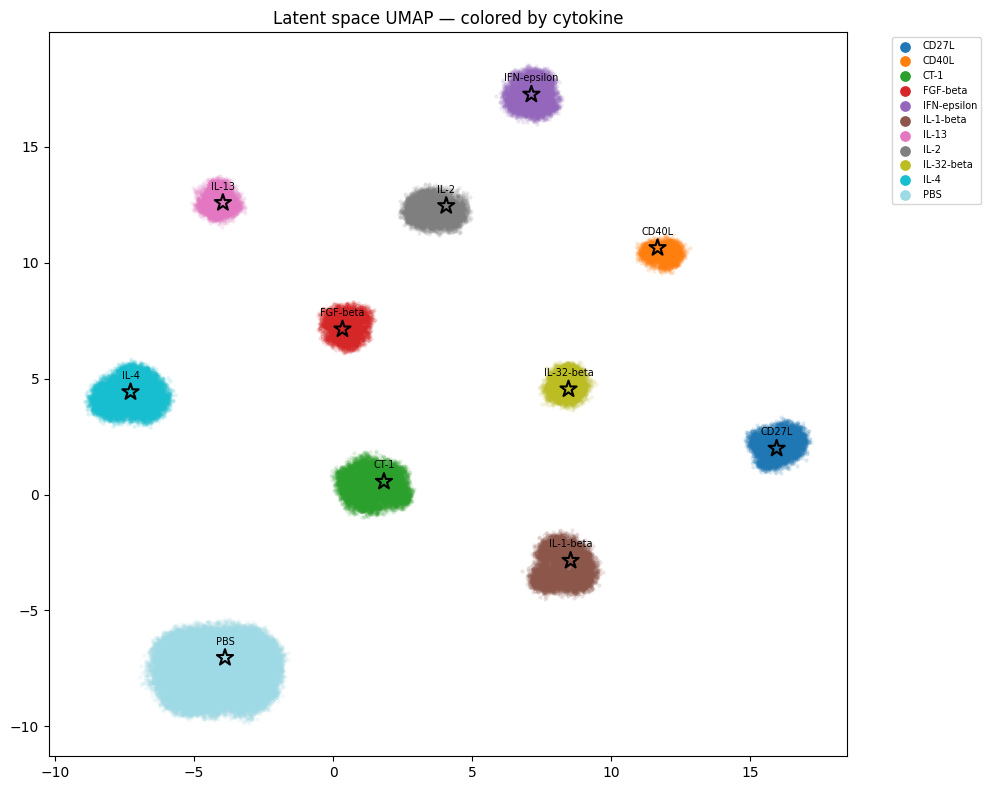

In [25]:
plot_latent_means_umap(analyzer)

In [26]:
def comapare_learned_vs_empirical_means(analyzer):
    latent_adata = create_latent_adata(analyzer.adata, analyzer.model, analyzer.device)

    empirical_means = []

    dataset = analyzer.kwargs_data["dataset"]
    perturbations = list(dataset.cats[0].categories)

    for key in perturbations:
        mask = analyzer.adata.obs[f"{analyzer.labels_key}"] == key
        empirical_means.append(latent_adata[mask].X.mean(axis=0))

    empirical_means = np.array(empirical_means)

    with torch.no_grad():
        learned_means = analyzer.model.means.cpu().numpy()

    return empirical_means, learned_means


def plot_learned_vs_empirical_means(empirical_means, learned_means, analyzer):

    dataset = analyzer.kwargs_data["dataset"]
    perturbations = list(dataset.cats[0].categories)

    n = len(perturbations)
    combined = np.concatenate([empirical_means, learned_means], axis=0)

    pca = PCA(n_components=2)
    combined_2d = pca.fit_transform(combined)
    empirical_2d = combined_2d[:n]
    learned_2d = combined_2d[n:]

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.get_cmap("tab10" if n <= 10 else "tab20")

    for i, label in enumerate(perturbations):
        color = cmap(i % cmap.N)
        ax.scatter(*empirical_2d[i], color=color, marker="o", s=80)
        ax.scatter(*learned_2d[i], color=color, marker="x", s=100)
        ax.annotate(label, empirical_2d[i], fontsize=8, alpha=0.8)

    # Legend explaining marker shapes (not per-perturbation, just style)
    ax.scatter([], [], color="black", marker="o", label="Empirical mean")
    ax.scatter([], [], color="black", marker="x", label="Learned mean")
    ax.legend(loc="best", fontsize=8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("Empirical vs. learned perturbation means (PCA)")
    fig.tight_layout()
    plt.savefig(
        os.path.join(analyzer.plot_dir, "empirical_vs_learned_means.png"), dpi=300
    )
    plt.show()

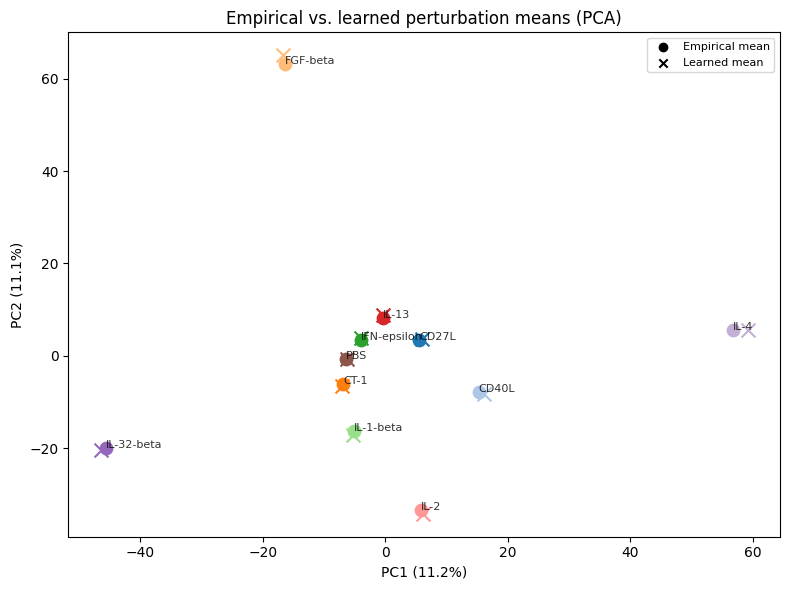

In [27]:
emp_means, learned_means = comapare_learned_vs_empirical_means(analyzer)
plot_learned_vs_empirical_means(emp_means, learned_means, analyzer)

### 3.2 Counterfactuals

In [16]:
key = "CT-1"

In [66]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

In [ ]:
(
    cfs_classifier,
    cfs_train_dataloader,
    cfs_test_dataloader,
    cfs_train_dataset,
    cfs_adata_train,
    cfs_num_classes,
) = init_classifier(
    analyzer_cfs, key, latent=False, hidden_dim=None, labels_key="origin"
)

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier,
    cfs_train_dataloader,
    cfs_test_dataloader,
    weights,
    analyzer_cfs.device,
    num_epochs=10,
)

100%|████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.41it/s]

Best Validation Accuracy: 0.9690


In [ ]:
evaluate_training_error(
    analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies
)

,Class,Accuracy
0,cfs,0.973211
1,original,0.930739


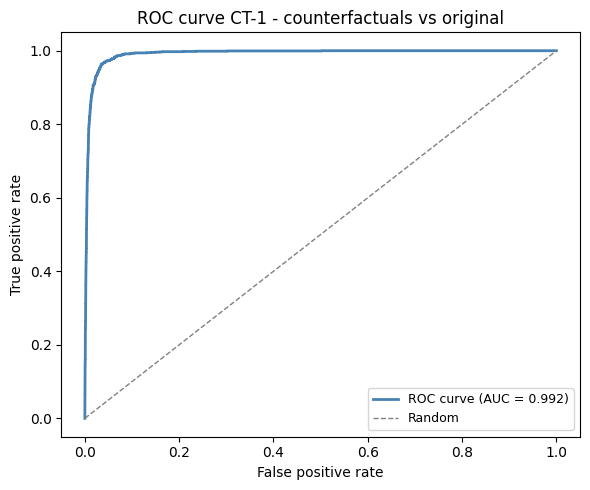

AUC: 0.992


In [69]:
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.3 MMD

In [28]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0002


: 

: 

: 

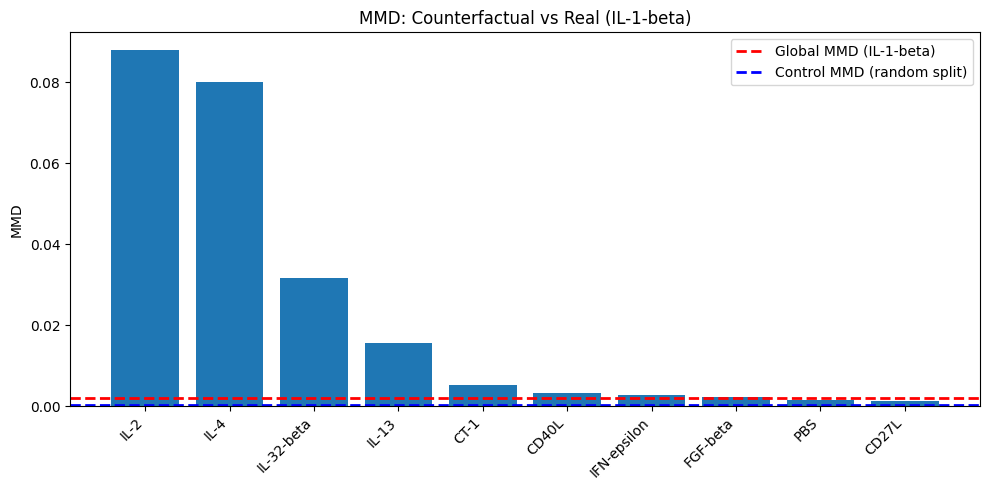

In [ ]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.4 Mean Expressions

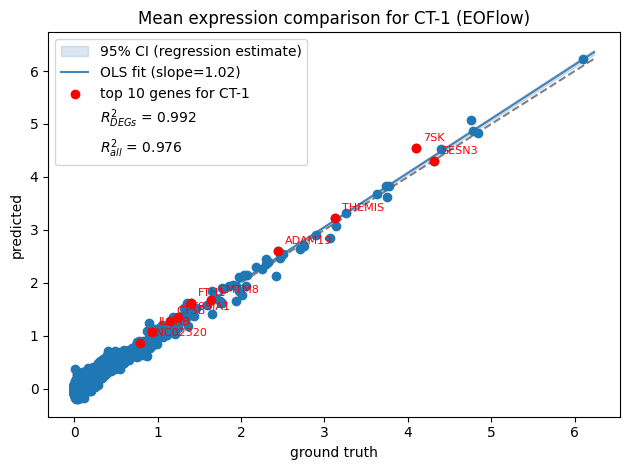

In [17]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, method="EOFlow")

### 3.5 Violin Plots

In [22]:
key = "CT-1"

In [23]:
from src.analysis.logistic_regression import generate_counterfactuals
from src.utils.utils import extract_top_genes, normalize_log1p
import scanpy as sc
import pandas as pd


def plot_top_deg_violin(
    analyzer, key, cfs_fn=generate_counterfactuals, log1p_transform=False, gene_idx=0
):
    top_gene_names, gene_indices = extract_top_genes(
        analyzer, key, top_n=20, log1p_transform=log1p_transform
    )
    gene_name = top_gene_names[gene_idx]
    gene_idx = gene_indices[gene_idx]

    def gene_values(adata_subset):
        x = (
            adata_subset.X.toarray()
            if hasattr(adata_subset.X, "toarray")
            else adata_subset.X
        )
        if log1p_transform:
            x = normalize_log1p(x)
        return x[:, gene_idx]

    control_values = gene_values(
        analyzer.adata[
            analyzer.adata.obs[analyzer.labels_key] == analyzer.control_label
        ]
    )
    key_values = gene_values(
        analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key]
    )

    x_cfs, z_cfs, all_source_labels, _ = cfs_fn(analyzer, key=key)
    # counterfactual = control cells predicted forward to `key`, matching the classic
    # ctrl -> stim comparison (rather than pooling counterfactuals from every source)
    cf_mask = np.asarray(all_source_labels) == analyzer.control_label
    cf_values = (
        x_cfs[cf_mask, gene_idx]
        .clip(
            min=0, max=1.1 * np.quantile(x_cfs[cf_mask, gene_idx].cpu().numpy(), 0.999)
        )
        .cpu()
        .numpy()
    )

    cf_label = f"{key} (counterfactual)"
    order = [analyzer.control_label, cf_label, key]
    values = np.concatenate([control_values, cf_values, key_values]).astype(np.float32)
    groups = (
        [analyzer.control_label] * len(control_values)
        + [cf_label] * len(cf_values)
        + [key] * len(key_values)
    )

    violin_adata = ad.AnnData(
        X=values.reshape(-1, 1),
        var=pd.DataFrame(index=[str(gene_name)]),
        obs=pd.DataFrame({"group": pd.Categorical(groups, categories=order)}),
    )

    ax = sc.pl.violin(
        violin_adata,
        keys=str(gene_name),
        groupby="group",
        order=order,
        use_raw=False,
        xlabel="",
        ylabel="expression",
        show=False,
    )
    ax.set_title(f"Top DEG for {key}: {gene_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(analyzer.plot_dir, f"top_deg_violin_{key}.png"), dpi=300)
    plt.show()

/scratch/jobs/59346144/ipykernel_266886/4001132797.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


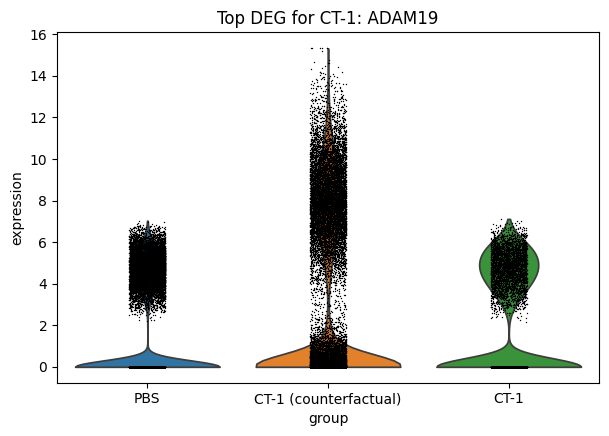

In [24]:
plot_top_deg_violin(analyzer, key=key, gene_idx=1)

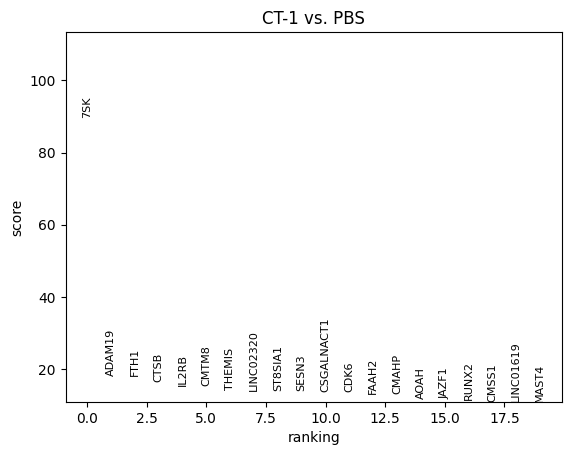

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1779 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: CD27L, CD40L, CT-1, etc.
var_group_labels: CT-1


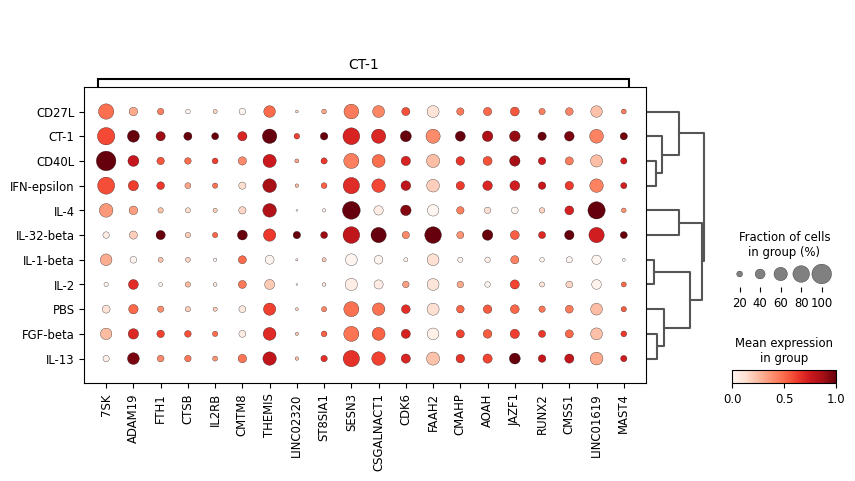

In [25]:
import scanpy as sc

sc.tl.rank_genes_groups(
    adata,
    groupby=analyzer.labels_key,
    groups=[key],
    reference=analyzer.control_label,
    method="wilcoxon",
)
sc.pl.rank_genes_groups(adata)
sc.pl.rank_genes_groups_dotplot(
    adata, groupby=f"{analyzer.labels_key}", standard_scale="var", n_genes=20
)

### 3.6 CF UMAP

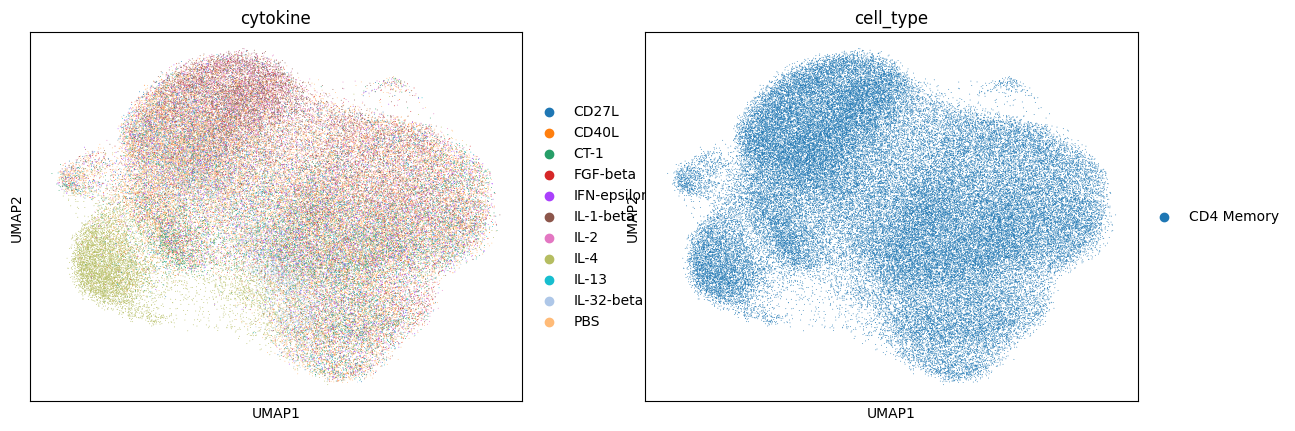

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 1779 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


<Figure size 640x480 with 0 Axes>

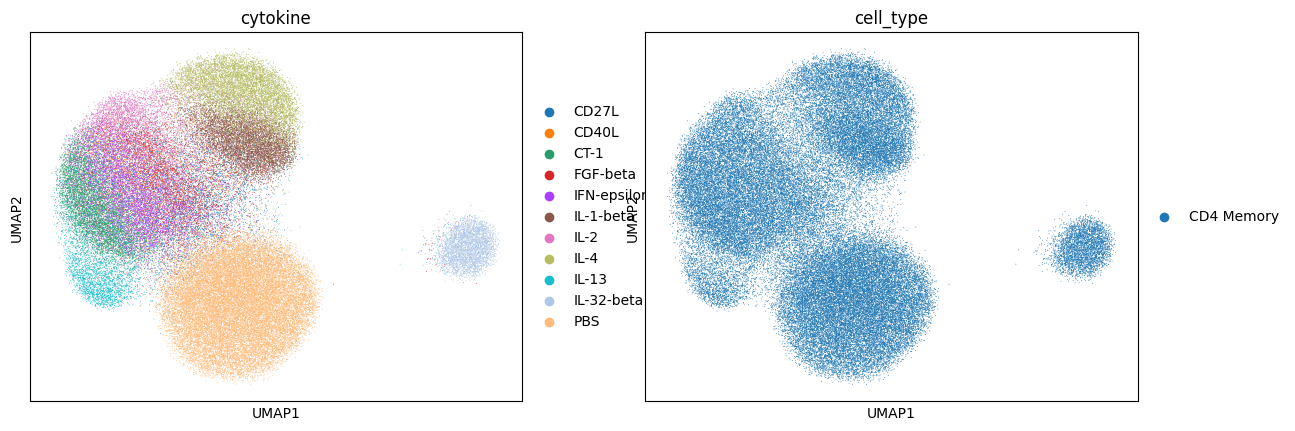

<Figure size 640x480 with 0 Axes>

In [29]:
adata_sampled = sample_from_means(analyzer, sigma=1.0)

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=[f"{labels_key}", "cell_type"])
plt.savefig(os.path.join(analyzer.plot_dir, f"umap_original.png"), dpi=300)

sc.pp.neighbors(adata_sampled)
sc.tl.umap(adata_sampled)
sc.pl.umap(adata_sampled, color=[f"{labels_key}", "cell_type"])
plt.savefig(os.path.join(analyzer.plot_dir, f"umap_sampled.png"), dpi=300)